# Idea
load model(s) and test them

# Imports

In [2]:
import os
# os.nice(19)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error, r2_score
from pathlib import Path
from utils.data_loader import find_repo_root
from utils.modeling import aggregate_multistep_predictions
import joblib

# Settings

In [3]:
sampling_rate = '5min'  # available: '20s', '1min', '5min'
start_time = '2024-07-24 00:00:00'
end_time = '2024-12-31 12:59:00'
columns =['orbital_decay', 'trend', '|avg B|', 'F10.7 (LASP)']
target = 'trend'
model_name = 'MultiTaskLassoCV'
model_No = 4
m = 15

# Load Data

In [4]:
DATA_DIR = find_repo_root() / Path("Dataset/modeling/")
DATA_file = DATA_DIR / Path(f"GFOC_modeling_{sampling_rate}.parquet")
GFOC_data = pd.read_parquet(DATA_file, columns=columns)
# filter by time range
GFOC_data = GFOC_data.loc[start_time:end_time]
print(f"✅ Successfully loaded data with shape: {GFOC_data.shape}")
# column names
print("Column names in the dataset:")
print(GFOC_data.columns.tolist())
print("Sample rate:", pd.infer_freq(GFOC_data.index))

X_file = DATA_DIR / Path(f"X_{sampling_rate}.parquet")
X_test = pd.read_parquet(X_file)
X_test = X_test.loc[start_time:end_time]
y_file = DATA_DIR / Path(f"y_{target}_{sampling_rate}.parquet")
y_test = pd.read_parquet(y_file)
y_test = y_test.loc[start_time:end_time]
print(f"✅ Successfully loaded features X_test with shape: {X_test.shape} and target y_test with shape: {y_test.shape}")

✅ Successfully loaded data with shape: (46236, 4)
Column names in the dataset:
['orbital_decay', 'trend', '|avg B|', 'F10.7 (LASP)']
Sample rate: 5min
✅ Successfully loaded features X_test with shape: (46224, 538) and target y_test with shape: (46224, 48)


# Load Model

In [5]:
MODEL_DIR = find_repo_root() / Path("Analysis/modeling/saved_models")
model = joblib.load(MODEL_DIR / f'{model_name}_{target}_model_{model_No}.pkl')
scaler = joblib.load(MODEL_DIR / f'{model_name}_{target}_scaler_{model_No}.pkl')

# Run Model

In [6]:
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    index=X_test.index,
    columns=X_test.columns
)

y_test_pred = pd.DataFrame(model.predict(X_test_scaled), index=X_test.index, columns=y_test.columns)

# Results

## Check Coefficients

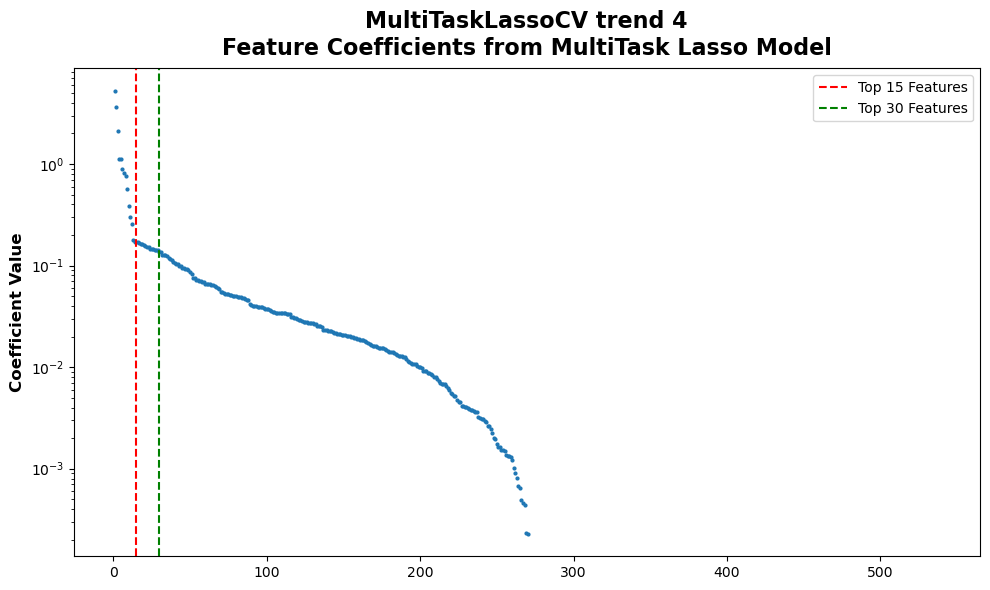

,feature,coefficient,lag_hours
523,median_decay_last_7D_lag_1,5.283343,0.08
533,median_decay_last_30D_lag_1,3.617486,0.08
516,F10.7 (LASP)_lag_1,2.116077,0.08
387,Flow Speed (km/s_lag_1,1.122584,0.08
527,median_decay_last_7D_lag_577,-1.121267,48.08
531,median_decay_last_14D_lag_433,-0.889448,36.08
530,median_decay_last_14D_lag_289,-0.812137,24.08
0,|avg B|_lag_1,0.764762,0.08
517,F10.7 (LASP)_lag_73,0.570241,6.08
129,Bz GSE_lag_1,-0.383656,0.08


In [7]:
dt_seconds = pd.to_timedelta(sampling_rate).total_seconds()

coef_df = pd.DataFrame({
    'feature': X_test.columns,
    'coefficient': model.coef_[1, :]
})
coef_df = coef_df.sort_values(by='coefficient', key=abs, ascending=False)
coef_df['lag_hours'] = coef_df['feature'].apply(lambda x: f"{int(x.split('_')[-1]) * (dt_seconds / 3600):.2f}" if 'lag' in x else np.nan)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(range(1,len(coef_df)+1), abs(coef_df['coefficient']), s = 4)
ax.axvline(x=15, color='red', linestyle='--', label='Top 15 Features')
ax.axvline(x=30, color='green', linestyle='--', label='Top 30 Features')
ax.set_ylabel('Coefficient Value')
ax.set_title(f'{model_name} {target} {model_No}\nFeature Coefficients from MultiTask Lasso Model')
ax.set_yscale('log')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

coef_df.head(10)

## Check alphas

The model has the attribute 'alphas_'.
Chosen alpha: 0.5878016072274914
        alpha  mean_cv_mse
39   0.010000    52.877467
38   0.011938    52.629150
37   0.014251    52.351751
36   0.017013    52.047175
35   0.020309    51.724736
34   0.024245    51.384732
33   0.028943    51.066615
32   0.034551    50.791955
31   0.041246    50.588101
30   0.049239    50.427740
29   0.058780    50.214825
28   0.070170    50.095318
27   0.083768    50.055620
26   0.100000    49.989300
25   0.119378    49.910701
24   0.142510    49.839517
23   0.170125    49.801005
22   0.203092    49.805273
21   0.242446    49.778422
20   0.289427    49.692081
19   0.345511    49.541067
18   0.412463    49.309699
17   0.492388    49.113581
16   0.587802    48.995436
15   0.701704    49.021936
14   0.837678    49.124935
13   1.000000    49.306795
12   1.193777    49.622585
11   1.425103    50.130415
10   1.701254    51.053087
9    2.030918    52.415186
8    2.424462    53.505046
7    2.894266    54.613912
6    3.455

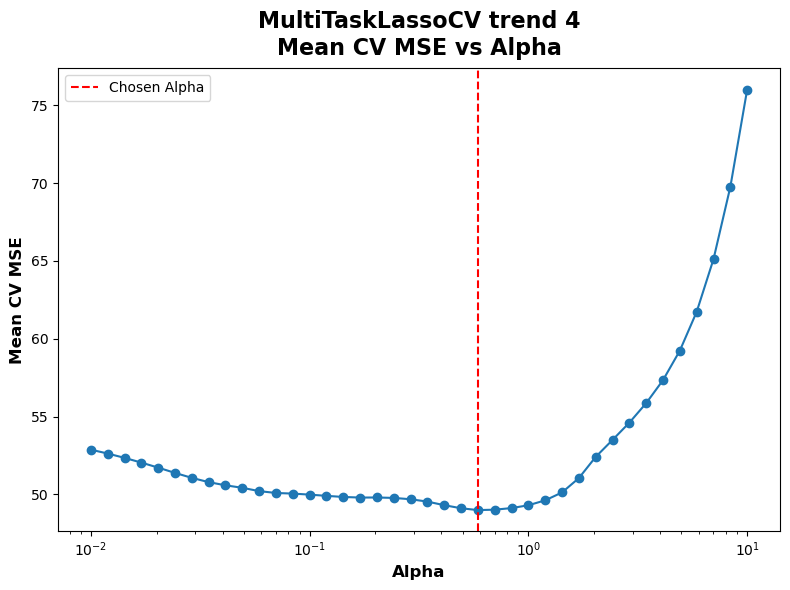

In [8]:
# check if model has an attribute alphas_
if not hasattr(model, 'alphas_'):
   print("The loaded model does not have the attribute 'alphas_'.")
else:
    print("The model has the attribute 'alphas_'.")
    best_alpha = model.alpha_
    print("Chosen alpha:", best_alpha)
    
# check if model has an attribute mse_path_
if not hasattr(model, 'mse_path_'):
   print("The loaded model does not have the attribute 'mse_path_'.")
else:
    alpha_mse_df = pd.DataFrame({
        "alpha": model.alphas_,
        "mean_cv_mse": model.mse_path_.mean(axis=1)
    }).sort_values("alpha", ascending=True)
    print(alpha_mse_df)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(alpha_mse_df['alpha'], alpha_mse_df['mean_cv_mse'], marker='o')
    ax.set_xscale('log')
    ax.set_xlabel('Alpha')
    ax.set_ylabel('Mean CV MSE')
    ax.set_title(f'{model_name} {target} {model_No}\nMean CV MSE vs Alpha')
    ax.axvline(best_alpha, color='red', linestyle='--', label='Chosen Alpha')
    ax.legend()
    plt.show()

## Check Test Error

Test RMSE: 11.5
Test R2: 0.271


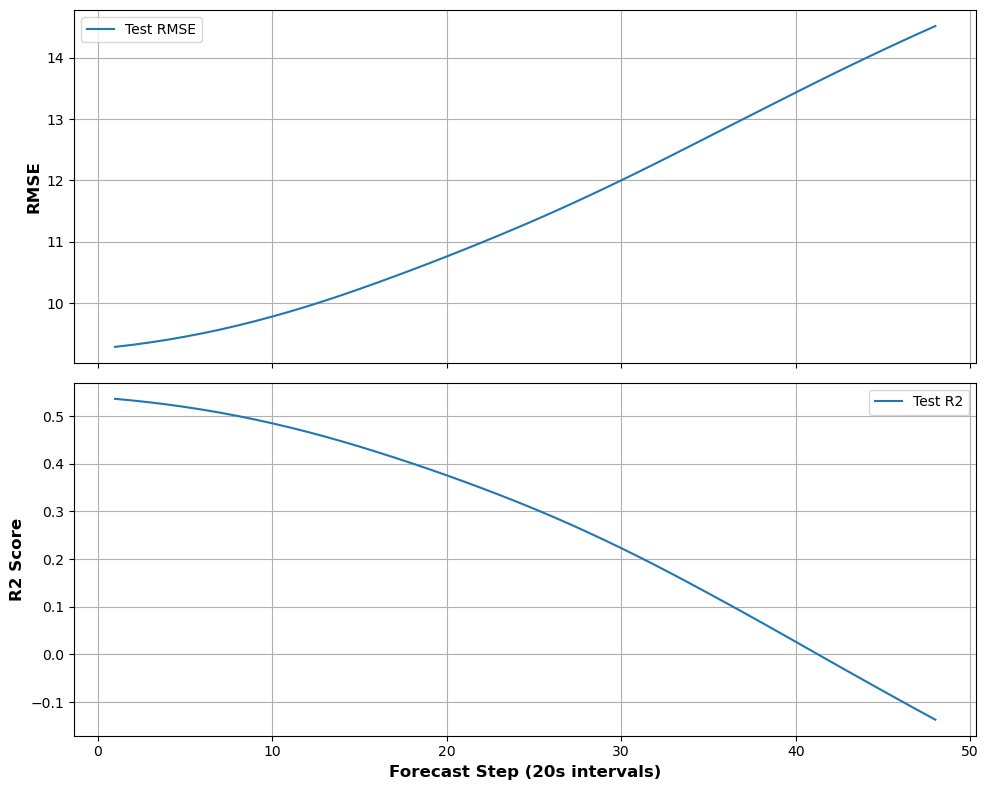

In [9]:
test_rmse = root_mean_squared_error(y_test, y_test_pred)
print((f"Test RMSE: {test_rmse:.3}"))
test_r2 = r2_score(y_test, y_test_pred)
print((f"Test R2: {test_r2:.3}"))

test_rmse_list = []
test_r2_list = []

for i in range(len(y_test.columns)):
    test_rmse_list.append(root_mean_squared_error(y_test.iloc[:, i], y_test_pred.iloc[:, i]))
    test_r2_list.append(r2_score(y_test.iloc[:, i], y_test_pred.iloc[:, i]))
fix, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
xtest = [int(col.split('_')[-1]) for col in y_test.iloc[0].index]
ax[0].plot(xtest,test_rmse_list, label='Test RMSE')
ax[0].set_ylabel('RMSE')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(xtest, test_r2_list, label='Test R2')
ax[1].set_ylabel('R2 Score')
ax[1].set_xlabel('Forecast Step (20s intervals)')
ax[1].legend()
ax[1].grid(True)
plt.tight_layout()
plt.show()

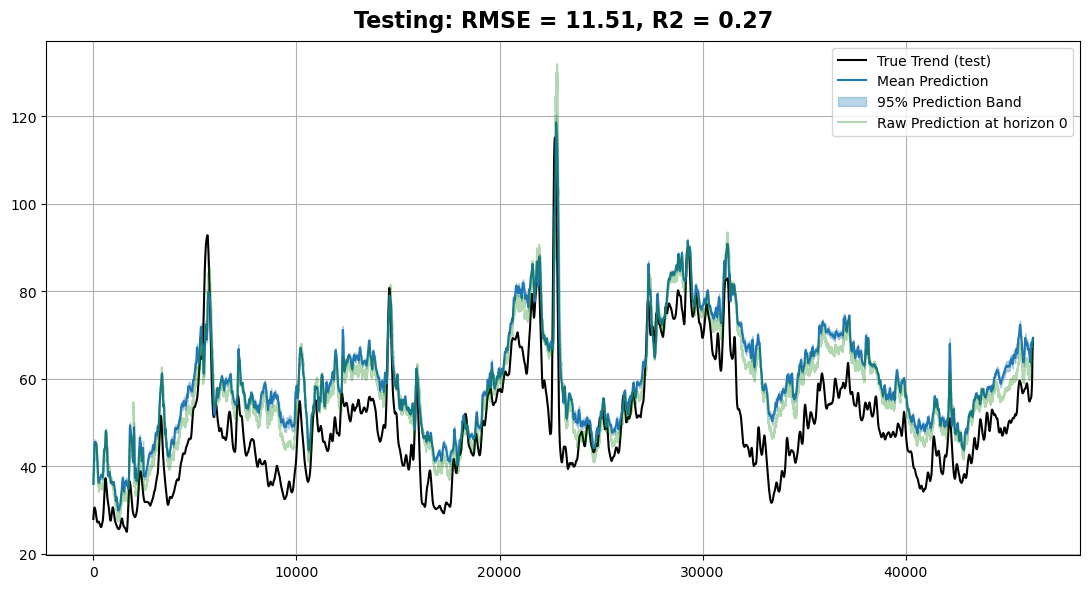

In [10]:
od_test = aggregate_multistep_predictions(y_test, dt_seconds=dt_seconds, error_kind='sem')
od_test_pred = aggregate_multistep_predictions(y_test_pred, dt_seconds=dt_seconds, error_kind='sem')

fig, ax = plt.subplots(1, 1, figsize=(11, 6))
test_range = range(len(od_test))
# plot complete forecast horizon
ax.plot(test_range, od_test['mean'], color='black')
ax.plot(test_range, od_test_pred['mean'], color='C0')
ax.fill_between(test_range, od_test_pred['mean'] - 1.96 *od_test_pred['sem'], od_test_pred['mean'] + 1.96 *od_test_pred['sem'], color='C0', alpha=0.3)
ax.plot(test_range, od_test_pred['horizon0'], color='green',  alpha=0.3)
_ = ax.legend(['True Trend (test)', 'Mean Prediction', '95% Prediction Band', 'Raw Prediction at horizon 0'])
ax.grid(True)
ax.set_title(f"Testing: RMSE = {root_mean_squared_error(y_test, y_test_pred):.2f}, R2 = {r2_score(y_test, y_test_pred):.2f}")
plt.tight_layout()
plt.show()

### Plot subsets

In [11]:
# split into subsets
NO_subsets = 10
splits = np.array_split(od_test.index, NO_subsets)
test_subsets = []
test_pred_subsets = []
for idx_chunk in splits:
    test_subsets.append(od_test.loc[idx_chunk])
    test_pred_subsets.append(od_test_pred.loc[idx_chunk])

In [12]:
def plot_subsets(true_subsets, pred_subsets, title_prefix):
    rows = len(true_subsets)
    i = 0
    fig, axes = plt.subplots(rows, 1, figsize=(11, 3*rows))

    if rows == 1:
        axes = [axes]

    for ax, df_true, df_pred in zip(axes, true_subsets, pred_subsets):
        ax.plot(df_true.index, df_true['mean'], color='black')
        ax.plot(df_pred.index, df_pred['mean'], color='C0')
        ax.fill_between(df_pred.index,
                        df_pred['mean'] - 1.96 * df_pred['sem'],
                        df_pred['mean'] + 1.96 * df_pred['sem'],
                        color='C0', alpha=0.3)
        ax.plot(df_pred.index, df_pred['horizon0'], color='green', alpha=0.3)

        ax.legend(['True Trend', 'Mean Prediction', '95% Prediction Band', 'Raw Prediction (horizon 0)'])
        ax.grid(True)

        subset_start = df_true.index.min().strftime('%Y-%m-%d %H:%M:%S')
        ax.set_title(f"{title_prefix} subset {i}, starting {subset_start}")
        i += 1

    plt.tight_layout()
    plt.show()


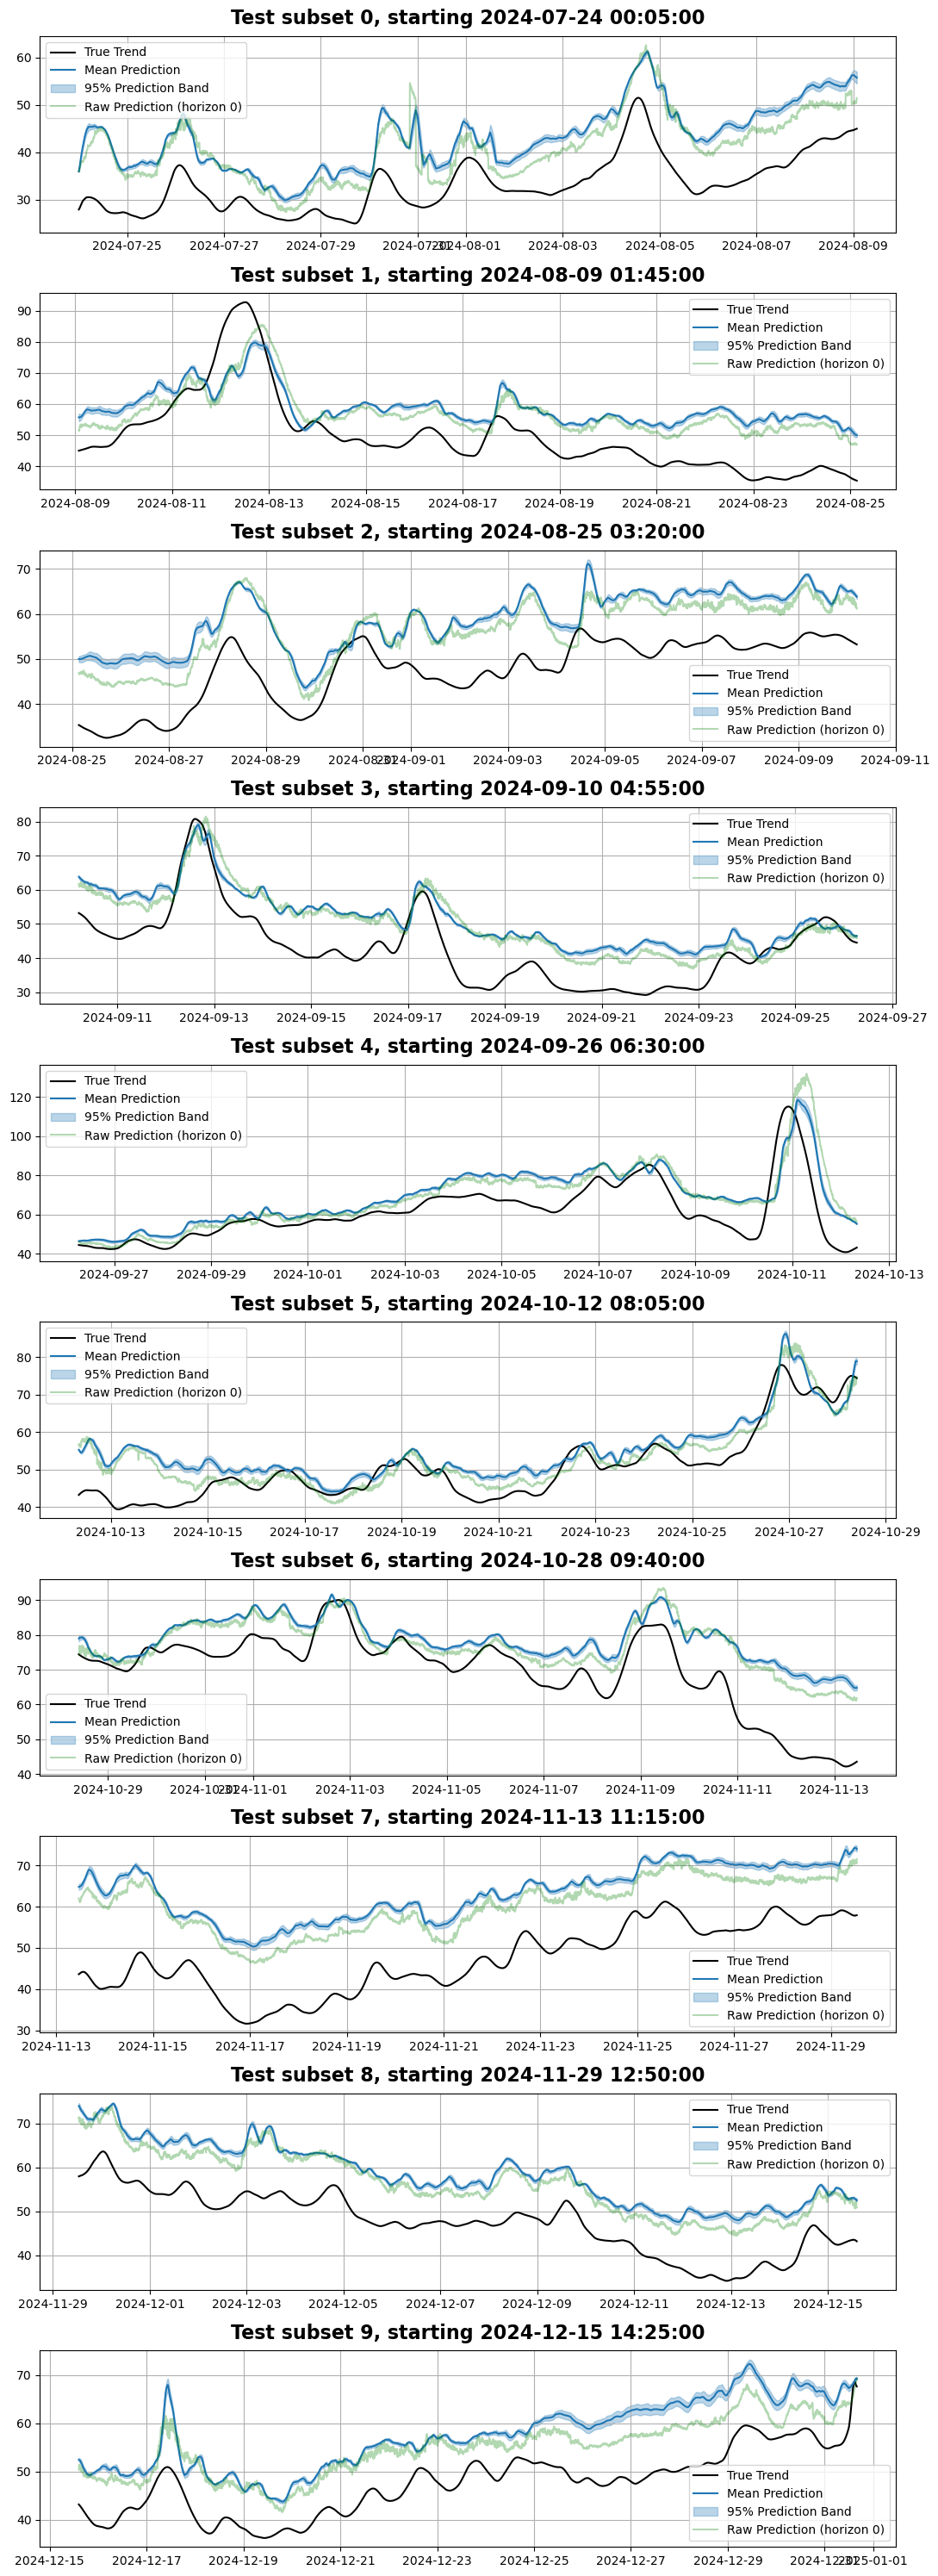

In [13]:
plot_subsets(test_subsets, test_pred_subsets, "Test")

## Plot single forecasts

In [14]:
def plot_forecast_for_event(event_id, time):
    idx = y_test.index.get_loc(time)
    time_idx = y_test.index[idx]

    # Extract sample
    sample_test = X_test.iloc[idx]
    sample_test_F = sample_test.filter(like='F10.7')
    sample_test_B = sample_test.filter(like='|avg B|')
    # sample_test_y = y_test.iloc[idx]

    # Compute lag times
    lag_times_F = [-int(col.split('_')[-1]) * dt_seconds / 60 for col in sample_test_F.index]
    lag_times_B = [-int(col.split('_')[-1]) * dt_seconds / 60 for col in sample_test_B.index]
    # lag_times_y = [int(col.split('_')[-1]) * dt_seconds / 60 for col in sample_test_y.index]

    sample_test_F.index = lag_times_F
    sample_test_B.index = lag_times_B

    # Define time window for decay plotting
    time_window = (time_idx - pd.Timedelta(hours=24), time_idx + pd.Timedelta(hours=24))
    true_decay = GFOC_data.loc[time_window[0]:time_window[1], target]
    pred_trend = y_test_pred.iloc[idx]
    bz_window = GFOC_data.loc[time_window[0]:time_window[1], '|avg B|']

    fig, ax = plt.subplots(figsize=(10, 6), nrows=2)
    ax = ax.flatten()

    # Plot lagged features
    ax[0].scatter(sample_test_F.index, sample_test_F.values, color='blue')
    ax2 = ax[0].twinx()
    ax2.scatter(sample_test_B.index, sample_test_B.values, color='orange', alpha=0.7)

    ax[0].set_title(f'Input lags for F10.7 and |avg B| for event id {event_id}\n{y_test.iloc[idx].name}')
    ax[0].set_xlabel('Lagged Features')
    ax[0].set_ylabel('F10.7 Value', color='blue')
    ax2.set_ylabel('|avg B| Value', color='orange')
    ax[0].grid(True)

    xticks = ax[0].get_xticks()
    ax[0].set_xticklabels([f'{int(t/60)}h' for t in xticks])

    # Plot decay trends
    ax[1].plot(true_decay.index, true_decay.values, label=f'True {target}', color='black')
    pred_times = [time_idx + pd.Timedelta(minutes=m * (i + 1)) for i in range(len(pred_trend))]
    ax[1].plot(pred_times, pred_trend.values, marker='.', linestyle='None', color='red', label=f'Predicted {target}')

    ax[1].set_title(f'Predicted {target} vs. True {target}')
    ax[1].set_xlabel('Time')
    ax[1].set_ylabel('Decay Rate (m/day)')
    ax[1].legend()
    ax[1].grid(True)

    # Overlay |avg B| on second plot
    ax2 = ax[1].twinx()
    ax2.scatter(bz_window.index, bz_window.values, color='blue', alpha=0.8, s=1)
    ax2.set_ylabel('|avg B|', color='blue')

    # Mark forecast horizon start time
    ax[1].axvline(time_idx, color='gray', linestyle='--', label='Forecast Horizon Start Time')

    plt.tight_layout()
    plt.show()

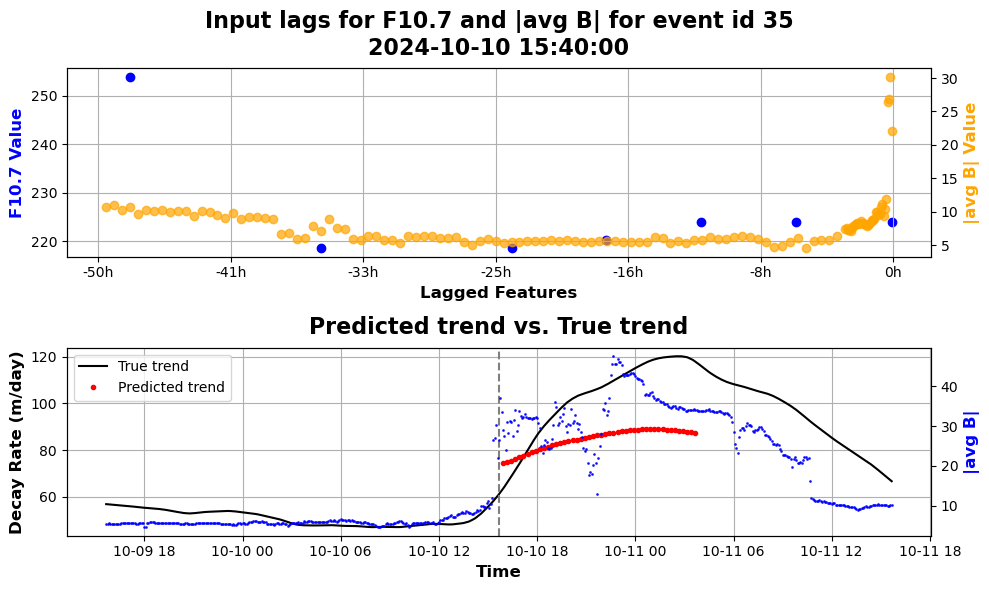

In [15]:
event_id = 35
event_time = '2024-10-10 15:40:00'
plot_forecast_for_event(event_id, event_time)